---
title: "American Option Pricing with Reinforcement Learning: A Hands-On Python Tutorial" 
author: "Peyman Kor"
date: 2025-07-21
description: " A short hands-on tutorial on option pricing with reinforcement learning"
categories: [rl, option] 
tags: [rl] 
image: "cover_image.png"
format:
  html:
    toc: true # Enable table of contents for better navigation
    toc-location: right # Position the TOC on the left
    #code-fold: true # Allow code folding for cleaner presentation
    number-sections: true # Number the sections in the output
    self-contained: true # Embed resources like CSSCan  and images into the HTML
    pdf:
      code-block-width: "80%"
      geometry:
        - margin=0.75in
        - textwidth=6.5in
      code-overflow: wrap
---

## Introduction to Option Pricing

American options are a type of financial derivative that give the holder the right, but not the obligation, to buy or sell an underlying asset at a specified price on or before a certain date. Two main types of American options are:

- **Call Option**: Gives the holder the right to buy the underlying asset at the strike price.
- **Put Option**: Gives the holder the right to sell the underlying asset at the strike price.

An example of how American option work would be useful. 

### Example: American Put Option

Imagine you have a put option on a stock with the following details:

- **Option Type**: American Put Option
- **Strike Price (K)**: $100
- **Underlying Asset Price (x)**: $95 initially - Day 0
- **Expiration Date**: 3 days from now
- **Premium (Initial Price of Option)**: $5

The above info is all the information you have about the option. However, you do not know how the price of underlying asset (can be simple Apple stock) will change over the next 3 days. 

To make example workable, let's assume the price of the underlying asset will change as follows:

- **Price of Underlying Asset over the next 3 days**:

   | Day | Asset Price (x) |
   |-----|-----------------|
   |  0  |      $95        |
   |  1  |      $92        |
   |  2  |      $90        |
   |  3  |      $97        |
 

The holder can choose to exercise the option at any time before or on the expiration date.

For example, lets assume the holder of the option exercises the option on day 2. This means the holder can sell the underlying asset for $100 (Strike Price, look up the put option definition) and buy back the stock at $92 (price of the underlying asset on day 2):

The profit of the holder is then:

$$
Profit = (K - x_t) - Premium
$$

$$
Profit = (100 - 92) - 5 = 3
$$


The holder can choose to exercise the option at any time before or on the expiration date. However, the question is **when is the optimal time to exercise the option?** (day 1, or day 2, or day 3?), and of course, you can not know the price of the underlying asset in the future, at day 0.


I think one visualization that can help to understand the option price is the following:


![Left: Profit for Call Option on y axis, function of x axis (underlying asset price) - Right: Profit for Put Option on y axis, function of x axis (underlying asset price)](option_exp.png){width=100% fig-alt="Chart showing number of days different platforms took to reach 1M users"}

As you can see from the chart below, on the right side of the chart (Put Option) the "Buyer" has profit if the price of the underlying asset is below the strike price (10 \$). However, if the price of underlying asset is above the strike price, the "Buyer" will lose money (equal to the premium paid (1\$))

 <div align="center">
 
 > **💡**  
 > The <b>Option Price</b> (or premium) is the maximum amount a holder is willing to pay to obtain the right to sell the underlying asset at the strike price, at any time before or on the expiration date.
 
 </div>


## American Option vs European Option

Before going to American Option, it is important to understand the difference between American Option and European Option. 

In American Option, the holder can exercise the option at **any time** before the expiration date. However, in European Option, the holder can only exercise the option at the expiration date.

Essentially, the flexibility that you have in American Option is the one you do not have in European Option. This flexibility comes with costs. American Option is more valuable than European Option.


The difference in the value of American Option and European Option can be attributed to having flexibility in American Option.

## American Option Pricing As Sequential Decision Making

American Option can be viewed as a sequential decision making problem. The holder of the option can choose to exercise the option at any time before the expiration date. The holder can also choose to hold the option until the expiration date.

Let's say you have American Option that expires in 10 days. At each from day 1 to day 10, you need to decide whether to sell (exercise) the option or hold (continue to hold). I tried to visualize this in the following figure:


![American Option as Sequential Decision Making](sdm_rl.png){width=100% fig-alt="Chart showing number of days different platforms took to reach 1M users"}

Now, we can think about what is the "profit" we get for each alternative we have:

- Alternative I: If we exercise the (put)option, the profit is known. It is $max(0, K-x_t)$, where $x_t$ is the stock price at time $t$ and $K$ is the strike price.
- Alternative II: If we hold the option, the profit is unknown. Therefore, we need to find an estimate of what will be the **Expected Value** of holding the option at the time.

If we know the Expected Value of holding the option at the time, we can just simply compare the two alternatives and choose the one higher. Simply:

- If $C(x_t, t) > max(0, K-x_t  )$, we should hold the option.

- If $C(x_t, t) < max(0, K-x_t)$, we should exercise the option.

Here, the $C(x_t, t)$ is the function that gives the idea about the Expected Value of holding the option at the time. It is a function of the stock price and the time.

In summary, the option price of the American Option can be divided into three steps:

1. Find the function $C(x_t, t)$
2. Compare $C(x_t, t)$ with $max(0, K-x_t)$ to decide when to stop and exercise the option.
3. Repeat the process for different paths (to account for underlying uncertainty) and find the average profit.

In the below schematic, I tried to visualize the process:

![Visualization of the American Option Pricing](schematic.png){width=100%}

## Reinforcement Learning

Reinforcement Learning is one learning paradigm that can be used to solve the problem of option pricing.The main idea in Reinforcement Learning is to learn the optimal policy (when to exercise the option) by interacting with the environment.

Think about a child that learns how to play football. The child first will try how shoot (imitating the others), then receive feedback (whether the shoot was goal or not), over time, through this interaction she learn to "reinforce" actions that generates higher reward.

In Reinforcement Learning, we have a similar process. We have an agent that interacts with the environment, and receives feedback (reward) based on the actions it takes. Over time, the agent learn to take actions that generates higher reward.

In the case of option pricing, the agent is the option holder, the environment is the stock market, and the reward is the profit. The agent needs to learn to take actions that generates higher profit.


![Reinforcement Learning workflow ](rlimage.png){width=100%}

As you can see the process of how Reinforcement Learning work is as follows:

1. The agent takes an action.
2. The agent receives feedback (reward) based on the action it takes.
3. The agent moves to new state, and need to take another action.

### Five Elements of Reinforcement Learning

To work with any Reinforcement Learning problem, we need to define the following five elements:

1. **Environment**: The environment is the world that the agent interacts with.
2. **Agent**: The agent is the entity that takes actions and learns from the environment.
3. **Action**: The action is the thing that the agent can do.
4. **State**: The state is the information that the agent has about the environment.
5. **Reward**: The reward is the feedback that the agent receives from the environment.



## Reinforcement Learning for American Option Pricing

As we discussed in the previous section, American Option pricing is a **sequential decision-making problem**: at each time step, the holder decides whether to exercise the option or continue holding it. This fits naturally into a **Reinforcement Learning (RL)** framework.

Here we need to translate the problem into a RL framework. The below is summary of the RL elements for option pricing.

### RL Elements for Option Pricing

- **State $s$**: Current time and asset price, $s = (t, x_t)$
- **Action $a$**:  
  - I) Exercise   
  - II) Continue 
- **Reward $r$**:  
  - If holding: $r = 0$  
  - If exercising: $r = \max(K - x_t, 0)$ for a put option (or $\max(x_t - K, 0)$ for a call)
- **Environment**: Interacting with the asset price that follow a stochastic process, (e.g Geometric Brownian Motion).
- **Agent**: The option holder, that needs to decide when to exercise the option.

### Q-Learning for Option Pricing

We follow simple Q learning approach as learning method in RL. In Q-learning method, we learn the function $Q(s, a)$ which is the **expected value of taking action $a$ in state $s$**, for all possible actions $a$. Note that for the action $a=exercise$, the expected value is the immediate exercise value $g(s)$. The main undertaking in Option Pricing is to estimate the expected value of the action $a=continue$. However, due to continuous nature of the underlying asset price, we build a function approximate to estimate the expected value of the action $a=continue$. Therefore, the Q function is written as $Q(s, a; w)$ that is a function of the state $s$ and the action $a$ and the weights $w$ of the function approximate.

$$
Q(s, a; w) = 
\begin{cases}
\mathbf{\Phi}(s)^T w & \text{if } a = \text{continue} \\
g(s) & \text{if } a = \text{exercise}
\end{cases} \tag{1}
$$

- $\mathbf{\Phi}(s)$: Feature vector 
- $w$: Weight vector (learned by RL)
- $g(s)$: Immediate exercise value (for the action $a=exercise$)

The feature vector $\mathbf{\Phi}(s)$ is constructed using Laguerre-like basis functions of the normalized asset price $\hat{x}_t = x_t / K$, where $K$ is the option's strike price. The same set of functions is also applied to normalized time $\hat{t} = t / T$, where $T$ is the expiry date.

The basis functions for the normalized price are:

$$
\begin{align*}
\phi_0(s) &= 1 \\
\phi_1(s) &= \exp\left(-\hat{x}_t / 2\right) \\
\phi_2(s) &= \exp\left(-\hat{x}_t / 2\right) \left(1 - \hat{x}_t\right) \\
\phi_3(s) &= \exp\left(-\hat{x}_t / 2\right) \left(1 - 2\hat{x}_t + \frac{1}{2}\hat{x}_t^2\right) \\
\phi_4(s) &= \exp\left(-\hat{x}_t / 2\right) \left(1 - 3\hat{x}_t + \frac{3}{2}\hat{x}_t^2\right) \\
\phi_5(s) &= \exp\left(-\hat{x}_t / 2\right) \left(1 - 4\hat{x}_t + 3\hat{x}_t^2 - \frac{1}{6}\hat{x}_t^3\right)
\end{align*}
$$

where $\hat{x}_t = x_t / K$. The same set of functions is applied to normalized time, replacing $\hat{x}_t$ with $\hat{t} = t / T$. In total, there are 12 feature functions (6 for price, 6 for time), and the weight vector $w$ has 12 elements. The feature vector $\mathbf{\Phi}(s)$ is a vector of features that are used to represent the state $s$.


$$
\mathbf{\Phi}(s) = [\phi_0(s), \phi_1(s), \ldots, \phi_5(s),\ \phi_6(s), \ldots, \phi_{11}(s)] \tag{2}
$$

### Learning the Optimal Policy

The RL algorithm (e.g., Least Squares Policy Iteration, LSPI) finds the weights $w^*$ that minimize the difference between predicted and actual rewards over many simulated experiences:

$$
L(w) = \sum_{i=1}^n \left[ Q(s_i, a_i; w) - (r_i + \gamma Q(s'_i, \pi(s'_i); w)) \right]^2 \tag{3}
$$

- $(s_i, a_i, r_i, s'_i)$: Experience tuple (state, action, reward, next state)
- $\gamma$: Discount factor
- $\pi(s'_i)$: Greedy policy (choose action with highest value at next state)

The above loss function is a simple mean squared error loss function. The RL algorithm finds the weights $w^*$ that minimize the loss function.

Replacing the $Q(s_i,a_i;w)$ with the right side of equation (1), and taking the semi-gradient of the objective function (2) with respect to the weights $w$ and setting it to zero, we get:

$$
\sum_i \mathbf{\Phi}(s_i) \cdot \left( \mathbf{\Phi}(s_i)^\top w^* - \lambda \cdot Q\left(s_i', \pi_D(s_i'); w^*\right) \right) = 0
\tag{4}
$$

The term $\pi_D(s_i')$ is a policy operator, where we need to apply the greedy policy. In the case of American options (AO), it is the $\max$ operator between the continuation and exercise values.


Equation (3) in matrix form can be written as:

$$
A \cdot w^* = b
$$
with
$$
A = \sum_i \mathbf{\Phi}(s_i) \left( \mathbf{\Phi}(s_i)^\top - IC_1 \cdot \gamma \cdot \mathbf{\Phi}(s_i')^\top \right)
$$
and
$$
b = \gamma \sum_i IC_2 \cdot \mathbf{\Phi}(s_i) \cdot g(s_i')
$$

The $m \times m$ matrix $A$ and $m \times 1$ (where $m$ is the size of the feature function vector, here $m=12$) matrix $b$ are accumulated at each atomic experience $(s_i, s_i')$:
$$
A \leftarrow A + \mathbf{\Phi}(s_i) \left( \mathbf{\Phi}(s_i)^\top - IC_1 \cdot \gamma \cdot \mathbf{\Phi}(s_i')^\top \right)
$$
$$
b \leftarrow b + \gamma \cdot IC_2 \cdot \mathbf{\Phi}(s_i) \cdot g(s_i')
$$

Thus, $w^*$ is solved as
$$
w^* = A^{-1} b \tag{5}
$$

and Equation (5) updates the Q-value function approximation $Q(s, a; w^*)$. The update of the Q-value function reflects the update in the “decision policy” (when to exercise the option) during the training phase of the Reinforcement Learning method. 








## Python Implementation

Before going to the code, let's first understand the bigger picture of how to workflow of coding.

![Overall view of code architecture](codingworkflow.png){width=100%}

Workflow steps are as follows:

1. First we use the price model (can be GBM, Heston, etc.) to generate the price paths. We need to generate the price paths for two purposes:
    - Training: We use the price paths to train the RL model.
    - Test: We apply the learned policy to the price paths to get the option price

2. Then the training data and featured vectors are used inside the RL algorithm to find the weights of the Q-function.

3. After we learn the weights of the Q-function, we can apply the learned policy to the test data to get the option price.


```
1. Generate Training Data (GBM paths)
   ↓
2. Calculate Feature Vectors
   ↓
3. Train Q-Learning Model
   ↓
4. Generate Test Data
   ↓
5. Apply Learned Policy (from step 3) and calculate the option price
```

### 1. Generating Training Data

Here, we use Geometric Brownian Motion (GBM) to generate the price paths.

In GBM, if $T$ and $S$ are two time points, the relationship between the prices at these two time points is given by:

$$log(x_T) \sim \mathcal{N}(log(x_S) + (\mu-\frac{\sigma^2}{2})(T-S), \sigma^2(T-S))$$

- Where:
    - $x_T$ is the price of the asset at time $T$
    - $\mu$ is the drift
    - $\sigma$ is the volatility

We can rewrite equation so that it is in terms of $x_T$:

$$x_T \sim  \exp(\mathcal{N}(log(x_S) + (\mu-\frac{\sigma^2}{2})(T-S), \sigma^2(T-S)))$$

Now we can generate the price paths for the training data.

In [2]:
from typing import List, Tuple
import numpy as np

# To manage the randomness, you can set the random seed for reproducibility:
np.random.seed(10)

def simulate_GBM_training(
    expiry_time: float,
    num_intervals: int,
    num_simulations: int,
    spot_price: float,
    interest_rate: float,
    volatility: float
) -> List[Tuple[int, float, float]]:

    """
    Generates simulated stock price data for training purposes.

    Parameters:
        expiry_time (float): expiration date (year).
        num_intervals (int): Number of exercise time steps.
        num_simulations (int): Number of independent price paths to generate.
        spot_price (float): Starting stock price, spot price
        interest_rate (float): Risk-free interest rate.
        volatility (float): Volatility of the stock price.

    Returns:
        List[Tuple[int, float, float]]: List of tuples containing (time step, current price, next price).
    """

    results = []
    time_step_size = expiry_time / num_intervals
    volatility_squared = volatility ** 2

    for _ in range(num_simulations):

        current_price = spot_price

        for step in range(num_intervals):
            mean = np.log(current_price) + (interest_rate - 0.5 * volatility_squared) * time_step_size
            variance = volatility_squared * time_step_size
            next_price = np.exp(np.random.normal(mean, np.sqrt(variance)))
            results.append((step, current_price, next_price))
            current_price = next_price

    return results

We need to define the parameters of the GBM model:

In [3]:
# data for training

expiry_time_val = 1
num_intervals_val = 50
num_simulations_val = 10000
spot_price_val = 36
strike_val = 40
interest_rate_val = 0.06
volatility_val = 0.2

In [4]:
RL_data_training = simulate_GBM_training(
    expiry_time=expiry_time_val,
    num_intervals=num_intervals_val,
    num_simulations=num_simulations_val,
    spot_price=spot_price_val,
    interest_rate=interest_rate_val,
    volatility=volatility_val
)

# Example of the first 3 data points
print(RL_data_training[:3])

[(0, 36, 37.41164023881166), (1, 37.41164023881166, 38.20678191352067), (2, 38.20678191352067, 36.60198653364306)]


The output of `print(RL_data_training[:3])` here shows the first three simulated steps from the generated Geometric Brownian Motion (GBM) training data.

If you look closer, each element in `RL_data_training` is a tuple of the form (step, current_price, next_price):
  - step: the time step index within a simulation path (from 0 up to num_intervals-1)
  - current_price: the simulated asset price at the time step $t$
  - next_price: the simulated asset price at the time step $t+1$, after applying the GBM update

Since there are multiple simulation paths, the data is a flat list of all steps from all simulations.

For example, the output might look like:
  [(0, 36, 37.41), (1, 37.41, 38.20), (2, 38.20, 36.60)]
This means:
  - At step 0, the price moved from 36 to 37.41
  - At step 1, the price moved from 37.41 to 38.20
  - At step 2, the price moved from 38.20 to 36.60



### 2. Calculate Feature Vectors


The feature vector $\Phi(s)$ is constructed using Laguerre-like basis functions of the normalized asset price $\hat{x}_t = x_t / K$, where $K$ is the option's strike price. The same set of functions is also applied to normalized time $\hat{t} = t / T$, where $T$ is the expiry date.

The basis functions for the normalized price are:

$$\phi_0(s) = 1$$

$$\phi_1(s) = \exp\left(-\hat{x}_t / 2\right)$$

$$\phi_2(s) = \exp\left(-\hat{x}_t / 2\right) \left(1 - \hat{x}_t\right)$$

$$\phi_3(s) = \exp\left(-\hat{x}_t / 2\right) \left(1 - 2\hat{x}_t + \frac{1}{2}\hat{x}_t^2\right)$$

$$\phi_4(s) = \exp\left(-\hat{x}_t / 2\right) \left(1 - 3\hat{x}_t + \frac{3}{2}\hat{x}_t^2\right)$$

$$\phi_5(s) = \exp\left(-\hat{x}_t / 2\right) \left(1 - 4\hat{x}_t + 3\hat{x}_t^2 - \frac{1}{6}\hat{x}_t^3\right)$$

The `make_feature_functions` function is used to create a list of feature functions that will be used to approximate the Q-function.

In [33]:
from numpy.polynomial.laguerre import lagval
from typing import List, Tuple, Callable

def make_feature_functions(t_s: Tuple[float, float],
        strike: float, expiry: float, num_laguerre:int=6) -> List[Callable[[Tuple[float, float]],
                                                                                             float]]:

    ident = np.eye(num_laguerre)

    def time_feature(t_s, i, expiry, ident):
        return np.exp(-t_s[0] / (2 * expiry)) * lagval(t_s[0] / expiry, ident[i])

    def price_feature(t_s, i, strike, ident):
        return np.exp(-t_s[1] / (2 * strike)) * lagval(t_s[1] / strike, ident[i])

    features: List[Callable[[Tuple[float, float]], float]] = []

    for i in range(num_laguerre):
        features.append(time_feature(t_s, i, expiry, ident))

    for i in range(num_laguerre):
        features.append(price_feature(t_s, i, strike, ident))

    return features

### 3. Train Q-Learning Model

The optimal weights $w^*$ are found by solving the linear system of equations.

In [34]:
import numpy as np

def get_weights(num_laguerre, expiry, num_steps, rate, training_data, strike_price,
                training_iters, epsilon):
    """
    Computes the weights for option pricing model using regression and feature functions.

    Parameters:
        num_laguerre (int): Number of Laguerre polynomials used in feature functions.
        expiry (float): Time to expiry of the option.
        num_steps (int): Number of time steps in the model.
        rate (float): Risk-free interest rate.
        training_data (List[Tuple[int, float, float]]): List of tuples (time step, current price, next price).
        strike (float): Strike price of the option.
        training_iters (int): Number of iterations for regression.
        epsilon (float): Regularization parameter for regression.

    Returns:
        np.ndarray: Calculated weights for the pricing model.
    """
    dt = expiry / num_steps
    gamma = np.exp(-rate * dt)
    num_features = num_laguerre * 2

    states = [(i * dt, s) for i, s, _ in training_data]
    next_states = [((i + 1) * dt, s1) for i, _, s1 in training_data]

    feature_vals = np.array([make_feature_functions(state, strike_price, expiry) for state in states])
    next_feature_vals = np.array([make_feature_functions(next_state, strike_price, expiry) for next_state in next_states])

    non_terminal_flags = np.array([index < num_steps - 1 for index, _, _ in training_data])
    exercise_value = np.array([max(strike_price - stock_price, 0) for _, stock_price in next_states])

    wts = np.ones(num_features)

    for _ in range(training_iters):

        a_inv = np.eye(num_features) / epsilon
        b_vec = np.zeros(num_features)
        cont = np.dot(next_feature_vals, wts)
        cont_cond = non_terminal_flags * (cont > exercise_value)

        for i in range(len(training_data)):
            phi1 = feature_vals[i]
            phi2 = phi1 - cont_cond[i] * gamma * next_feature_vals[i]

            # Sherman-Morrison formula for matrix a_inv
            temp = a_inv.T.dot(phi2)
            a_inv -= np.outer(a_inv.dot(phi1), temp) / (1 + phi1.dot(temp))
            # Sherman-Morrison formula fro matrix a_inv

            # matrix b update according to the formula
            b_vec += phi1 * (1 - cont_cond[i]) * exercise_value[i] * gamma

        wts = a_inv.dot(b_vec)
        #print(b_vec)
        #print(wts)
        #print(a_inv)

    return wts

In [35]:
# Example usage
num_laguerre_val = 6
training_iters_val = 4
epsilon_val = 1e-5
strike_val = 40

weights = get_weights(num_laguerre=num_laguerre_val, expiry=expiry_time_val, num_steps=num_intervals_val,
                        rate=interest_rate_val, training_data=RL_data_training, strike_price=strike_val,
                        training_iters=training_iters_val, epsilon=epsilon_val)

print("Weights: ", weights)

Weights:  [ -554.51448774   617.53175068  -396.44157314   -84.64166498
   266.87967408  -102.40787482   110.1107564   1186.26095963
 -1564.07348061  -832.39036942  2635.94651985 -1332.3132658 ]


So the result of the previous code chunk is the optimal "Weights" of the Q-function.

<div style="overflow-x:auto;">
$$w^* = [-554.51, 617.53, -396.44, -84.64, 266.87, -102.40, 110.11, 1186.26, -1564.07, -832.39, 2635.94, -1332.31]$$
</div>



Having the $w^*$ vector, we can calculate the Q-function for each state-action pair:

<div style="overflow-x:auto;">
$$Q(s, a; w^*) = -554.51 \cdot \phi_0(s, a) + 617.53 \cdot \phi_1(s, a) - 396.44 \cdot \phi_2(s, a) - 84.64 \cdot \phi_3(s, a) + 266.87 \cdot \phi_4(s, a) - 102.40 \cdot \phi_5(s, a) + 110.11 \cdot \phi_6(s, a) + 1186.26 \cdot \phi_7(s, a) - 1564.07 \cdot \phi_8(s, a) - 832.39 \cdot \phi_9(s, a) + 2635.94 \cdot \phi_{10}(s, a) - 1332.31 \cdot \phi_{11}(s, a)$$
 </div>

### 4. Generate Test Data

In [5]:
def scoring_sim_data(
    expiry_time: float,
    num_intervals: int,
    num_simulations_test: int,
    spot_price: float,
    interest_rate: float,
    volatility: float
) -> np.ndarray:

    paths: np.ndarray = np.empty([num_simulations_test, num_intervals + 1])
    time_step_size = expiry_time / num_intervals

    #vol2: float = volatility * volatility
    volatility_squared = volatility ** 2

    for i in range(num_simulations_test):
        paths[i, 0] = spot_price
        for step in range(num_intervals):
            mean: float = np.log(paths[i, step]) + (interest_rate - volatility_squared / 2) * time_step_size
            variance = volatility_squared * time_step_size
            paths[i, step + 1] = np.exp(np.random.normal(mean, np.sqrt(variance)))
    return paths[:,1:]

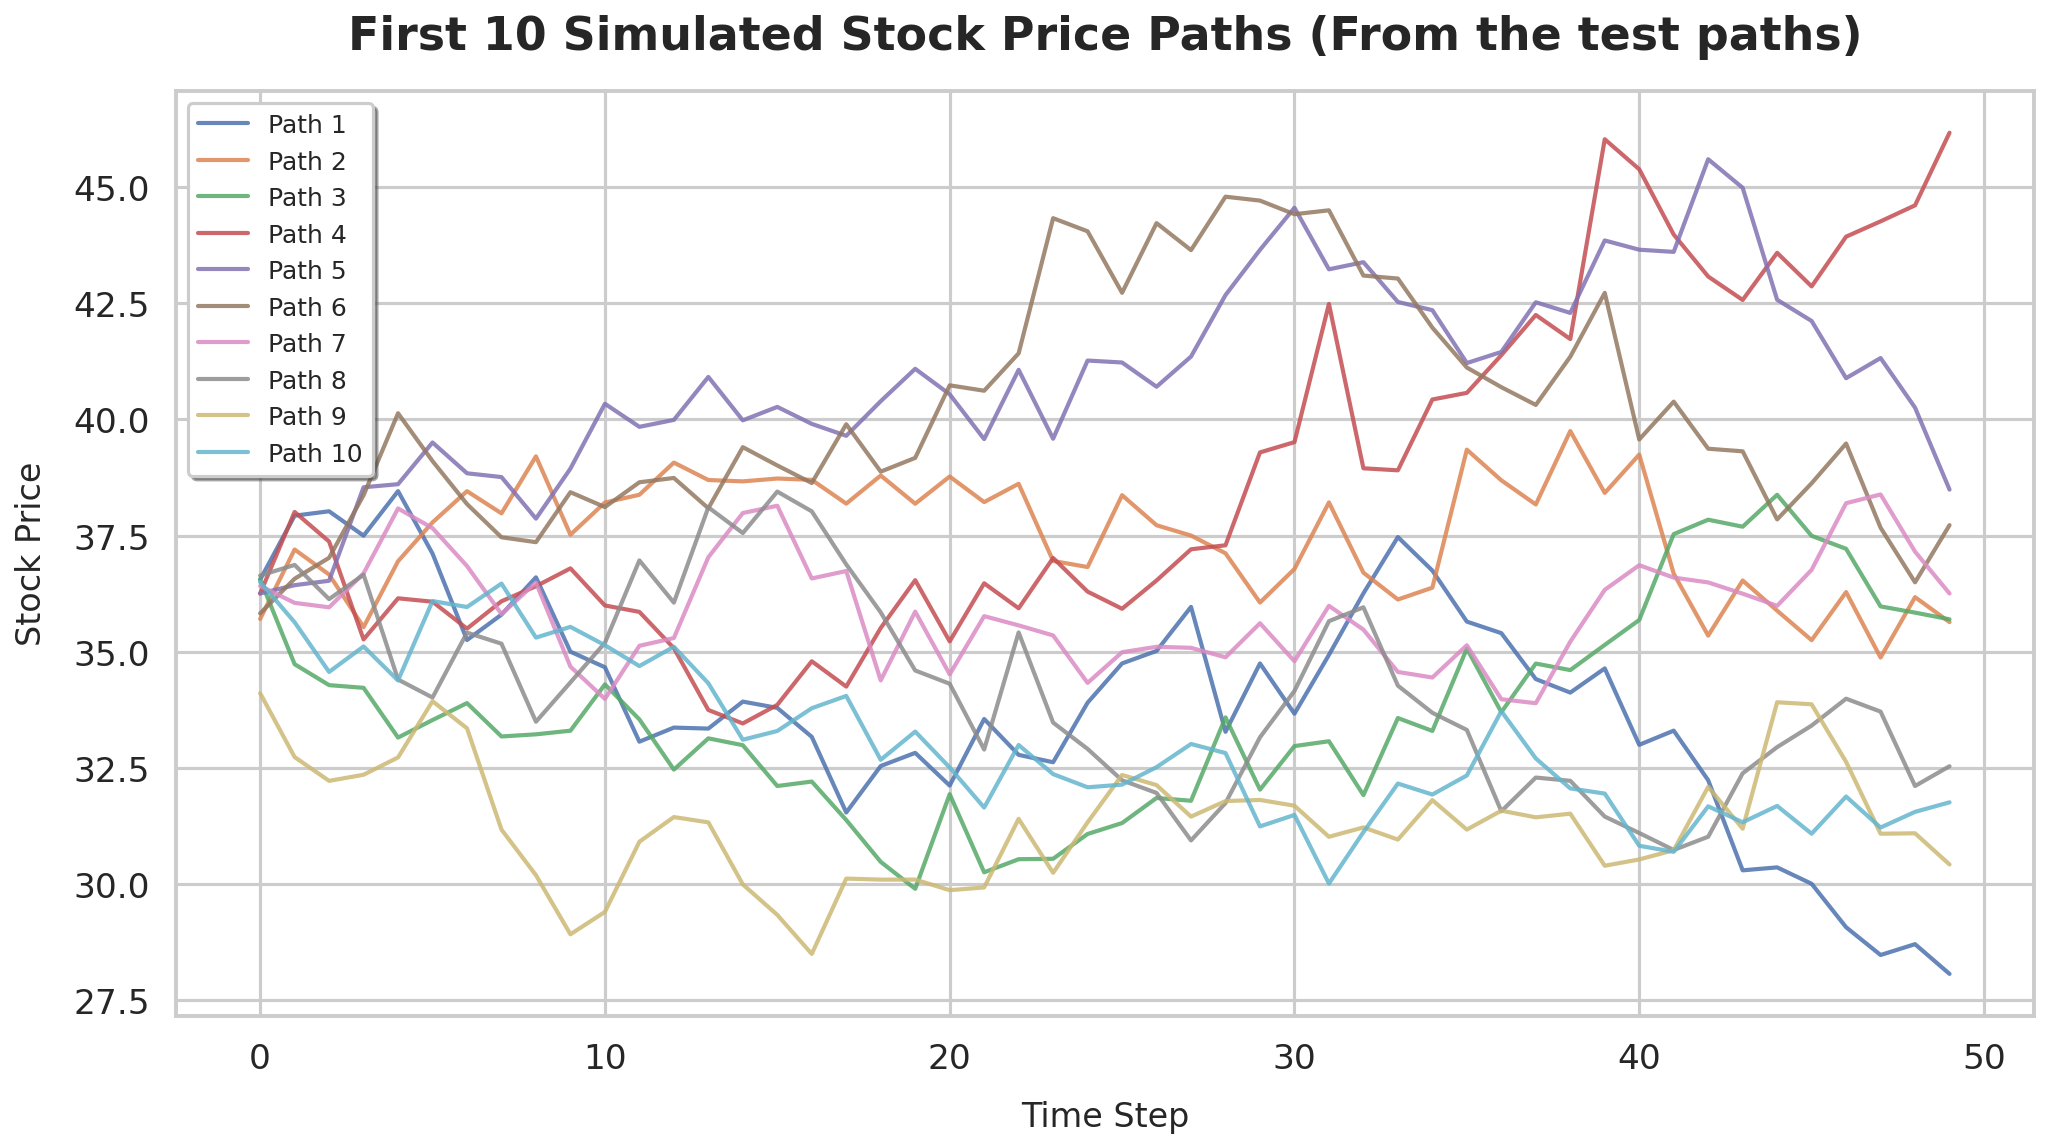

In [14]:
num_simulations_test = 10000

paths_test = scoring_sim_data(
    expiry_time=expiry_time_val,
    num_intervals=num_intervals_val,
    num_simulations_test=num_simulations_test,
    spot_price=spot_price_val,
    interest_rate=interest_rate_val,
    volatility=volatility_val
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk", palette="deep")

plt.figure(figsize=(14, 8), dpi=150)
for i in range(10):
    plt.plot(
        paths_test[i], 
        label=f'Path {i+1}', 
        linewidth=2, 
        alpha=0.85
    )
plt.title('First 10 Simulated Stock Price Paths (From the test paths)', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Time Step', fontsize=16, labelpad=12)
plt.ylabel('Stock Price', fontsize=16, labelpad=12)
plt.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

# Also save the plot in high quality
#plt.figure(figsize=(14, 8), dpi=300)


In [ ]:
#num_simulations_test = 10000

#paths_test = scoring_sim_data(
#    expiry_time=expiry_time_val,
#    num_intervals=num_intervals_val,
#    num_simulations_test=num_simulations_test,
#    spot_price=spot_price_val,
#    interest_rate=interest_rate_val,
#    volatility=volatility_val
#)

#import matplotlib.pyplot as plt
#import seaborn as sns

#sns.set(style="whitegrid", context="talk", palette="deep")

#plt.figure(figsize=(14, 8), dpi=150)
#for i in range(10):
#    plt.plot(
#        paths_test[i], 
#        label=f'Path {i+1}', 
#        linewidth=2, 
#        alpha=0.85
#    )
# plt.title('Simulation of Stock Price Paths (n=10)', fontsize=22, fontweight='bold', pad=20)
#plt.xlabel('Time Step', fontsize=16, labelpad=12)
#plt.ylabel('Stock Price', fontsize=16, labelpad=12)
#plt.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)
#plt.tight_layout()
#plt.savefig('stock_paths_test.png', dpi=300, bbox_inches='tight')
#plt.close()
#plt.show()

In the graph above, we can see the first 10 simulated stock price paths.


### 5. Apply Learned Policy (from step 3) and calculate the option price


In [38]:
def calculate_option_price(
    stock_paths: np.ndarray,     # This is a 2D array with stock price paths
    option_expiry: float,        # The time until the option expires, in years
    interest_rate: float,        # The annual interest rate, as a decimal
    strike_price: float,
    weights_rl: List           # The price at which the option can be exercised
) -> float:
    # Number of different price paths

    num_paths = stock_paths.shape[0]
    # Number of time steps in each path
    num_time_steps = stock_paths.shape[1]

    # This will hold the final option prices for each path
    option_prices = np.zeros(num_paths)
    # Time interval between steps
    dt = option_expiry / num_time_steps

    # Loop over each stock price path
    for path_index, price_path in enumerate(stock_paths):
        # Process each time step in the path
        time_step = 1
        while time_step <= num_time_steps:
            # Calculate the current time in years
            current_time = time_step * dt
            # Get the stock price at the current step
            current_stock_price = price_path[time_step - 1]
            # Calculate the profit if the option is exercised now
            exercise_value = max(strike_price - current_stock_price, 0)
            # Simulate the feature values for mathematical modeling (using a placeholder function)
            state = (current_time, current_stock_price)
            feature_values = make_feature_functions(state, strike_price, option_expiry)
            # Calculate the theoretical price if waiting (using machine learning or some model)
            continue_price = np.dot(feature_values, weights_rl) if time_step < num_time_steps else 0

            # Increment the time step
            time_step += 1
            # Decide whether to exercise the option now or later
            if (exercise_value >= continue_price) and (exercise_value > 0):
                # Update the price for this path and discount it by the interest rate
                option_prices[path_index] = np.exp(-interest_rate * current_time) * exercise_value
                # Move to the end of the path since we've decided to exercise the option
                time_step = num_time_steps + 1

    # Return the average of the option prices across all paths
    return np.average(option_prices)

In [39]:
option_price = calculate_option_price(
    stock_paths=paths_test,
    option_expiry=expiry_time_val,
    interest_rate=interest_rate_val,
    strike_price=strike_val,
    weights_rl=weights
)
print("Option Price using RL Method:", option_price)

Option Price using RL Method: 4.461213286722788


## Comparison with the traditional method (LSMC)

One a more traditional method for pricing American Options is the Least Squares Monte Carlo (LSMC) method. This method is based on the idea of using the Monte Carlo method to price the option. I refer readers to the following paper for more details:

[Valuing American Options by Simulation: A Simple Least-Squares Approach, by Longstaff and Schwartz](https://people.math.ethz.ch/~hjfurrer/teaching/LongstaffSchwartzAmericanOptionsLeastSquareMonteCarlo.pdf)


You can also, find a simple implementation of the LSMC method in the following link


[A Complete Step-by-Step Guide for Pricing American Option](https://medium.com/datadriveninvestor/a-complete-step-by-step-guide-for-pricing-american-option-712c84aa254e)


However, the goal here is to compare the performance of the RL method with the LSMC method. To do this, I am going to compare the result of the RL method with the result of the LSMC method, according to Table 1 in the LSMC paper:


![Table 1 in the LSMC paper](lsmctable.png)





For the first row of the table, we have the following parameters:

- Initial Stock Price: 36$
- Strike Price: 40$
- Expiry: 1 year
- Volatility: 20% (annualized)
- Interest Rate: 0.06

The results of the RL method and the LSMC method can be compared in the table below. The RL method price is computed in the next cell.



In [40]:
print("American Option Price using RL Method:", option_price)

American Option Price using RL Method: 4.461213286722788


| Method         | American Option Price ($) |
|---------------|--------------------------|
| LSMC          | 4.472                    |
| RL            | 4.461                    |

## Summary and Key Takeaways

In this hands-on tutorial, I explored how you can use Reinforcement Learning to price American put options. I started with basics of Option pricing, then explained how American option can be viewed as **Sequential Decision-Making**. Then, Q-learning approach was used to price the option.


The key insight is that option pricing becomes a "when to exercise" problem - at each time step, we must decide whether to exercise the option immediately or continue holding it. As it leads to a sequential decision-making problem, Reinforcement Learning provides a natural framework for learning this optimal exercise policy through simulated market interactions.

In brief comparison, the RL implementation achieved a price of $4.461 for the American put option, which closely matches the traditional LSMC method result of $4.472, demonstrating the effectiveness of the RL approach.

### Key Takeaways

• **American options are sequential decision problems** - The holder must decide at each time step whether to exercise or continue holding the option

• **Reinforcement Learning fits naturally** - The option holder becomes the agent, the stock market is the environment, and profit is the reward

• **Q-learning with function approximation works well** - Using Laguerre basis functions to approximate the Q-function provides good results for continuous state spaces

• **Simulation-based training is powerful** - Generating thousands of price paths with GBM allows the RL agent to learn optimal exercise strategies